# Mini project 1 SHBT261

**Author:** Anakin (Jiaqi) Li
**Date:** 2026-03

---

## Overview
| # | Method | Type |
|---|--------|------|
| 1 | HOG + SVM | Classical ML |
| 2 | ResNet-50 | Deep Learning (CNN) |
| 3 | EfficientNet-B0 | Deep Learning (CNN) |
| 4 | ViT-Small | Deep Learning (Transformer) |

---

## Environment Setup

### Installation
```powershell
python -m venv .venv
.venv\Scripts\Activate.ps1

python -m pip install --pre torch torchvision --index-url https://download.pytorch.org/whl/nightly/cu128

python -m pip install -r requirements.txt

python -m pip install jupyterlab

jupyter lab
```

## Section 0
### Imports

In [1]:
# ── Standard Library
import os
import random
import warnings
warnings.filterwarnings("ignore")

# ── Numerical & Data
import numpy as np
import pandas as pd

# ── Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Image Processing
from PIL import Image
import cv2
from skimage.feature import hog
from skimage import exposure

# ── Classical ML
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

# ── PyTorch Core
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# ── ViT via timm
import timm

# ── Grad-CAM
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Progress Bar
from tqdm import tqdm

# ── Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ── Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
print(f"Using device    : {device}")

PyTorch version : 2.12.0.dev20260301+cu128
CUDA available  : True
GPU             : NVIDIA GeForce RTX 5070 Ti Laptop GPU
Using device    : cuda


## Section 1 — Dataset Loading & Train/Val/Test Split

**Dataset:** Caltech-101 — 101 object categories, ~9,000 images  
**Download:** https://www.kaggle.com/datasets/imbikramsaha/caltech-101  
**Split:** Stratified 70% train / 15% val / 15% test

In [2]:
# Global config
DATA_ROOT   = "C:/Users/anaki/Desktop/SHBT261/Proj1/caltech-101" 
IMG_SIZE    = 224   # default size for DL models
HOG_SIZE    = 128   # size for HOG feature extraction
BATCH_SIZE  = 32
NUM_EPOCHS  = 15
LR          = 1e-4
NUM_WORKERS = 0
NUM_CLASSES = 101

# ImageNet normalization for later use
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

In [3]:
from collections import Counter

all_paths, all_labels = [], []

for class_name in sorted(os.listdir(DATA_ROOT)):
    class_dir = os.path.join(DATA_ROOT, class_name)
    if not os.path.isdir(class_dir):
        continue
    if class_name == "BACKGROUND_Google":  # skip background clutter
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            all_paths.append(os.path.join(class_dir, fname))
            all_labels.append(class_name)

# Encode string labels to integers
le = LabelEncoder()
all_labels_enc = le.fit_transform(all_labels)
class_names = list(le.classes_)

print(f"Total images  : {len(all_paths)}")
print(f"Total classes : {len(class_names)}")
print(f"Example classes: {class_names[:5]}")

Total images  : 8677
Total classes : 101
Example classes: [np.str_('Faces'), np.str_('Faces_easy'), np.str_('Leopards'), np.str_('Motorbikes'), np.str_('accordion')]


In [4]:
# First 15% test
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels_enc,
    test_size=0.15, random_state=42, stratify=all_labels_enc
)

# Then split remaining 85% into 70% train and 15% val
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.15 / 0.85, random_state=42, stratify=train_val_labels
)

print(f"Train : {len(train_paths):>5} images  ({len(train_paths)/len(all_paths)*100:.1f}%)")
print(f"Val   : {len(val_paths):>5} images  ({len(val_paths)/len(all_paths)*100:.1f}%)")
print(f"Test  : {len(test_paths):>5} images  ({len(test_paths)/len(all_paths)*100:.1f}%)")

Train :  6073 images  (70.0%)
Val   :  1302 images  (15.0%)
Test  :  1302 images  (15.0%)


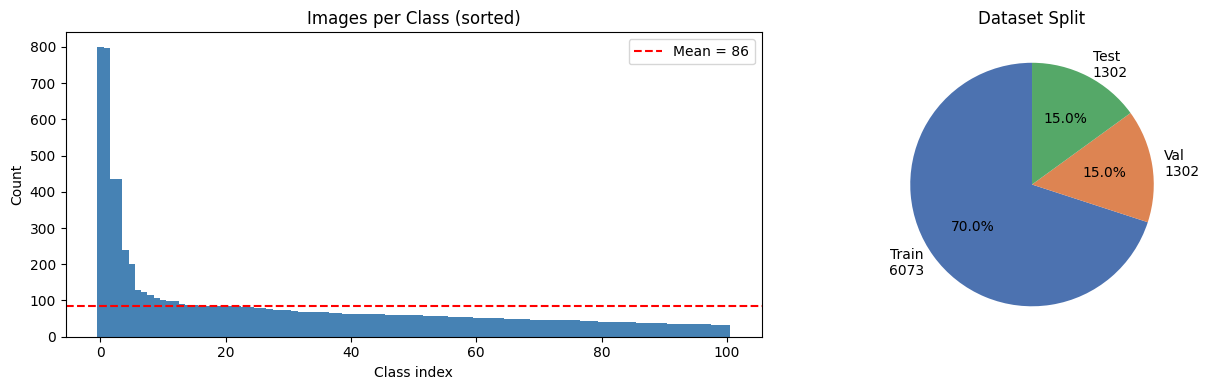

Min: 31  |  Max: 800  |  Mean: 85.9  |  Std: 117.8


In [5]:
label_counts = Counter(all_labels)
counts = sorted(label_counts.values(), reverse=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# images per class
axes[0].bar(range(len(counts)), counts, color="steelblue", width=1.0)
axes[0].axhline(np.mean(counts), color="red", linestyle="--",
                label=f"Mean = {np.mean(counts):.0f}")
axes[0].set_title("Images per Class (sorted)")
axes[0].set_xlabel("Class index")
axes[0].set_ylabel("Count")
axes[0].legend()

# train / val / test split sizes
axes[1].pie(
    [len(train_paths), len(val_paths), len(test_paths)],
    labels=[f"Train\n{len(train_paths)}", f"Val\n{len(val_paths)}", f"Test\n{len(test_paths)}"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452", "#55A868"],
    startangle=90
)
axes[1].set_title("Dataset Split")

plt.tight_layout()
plt.savefig("fig_s1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Min: {min(counts)}  |  Max: {max(counts)}  |  Mean: {np.mean(counts):.1f}  |  Std: {np.std(counts):.1f}")

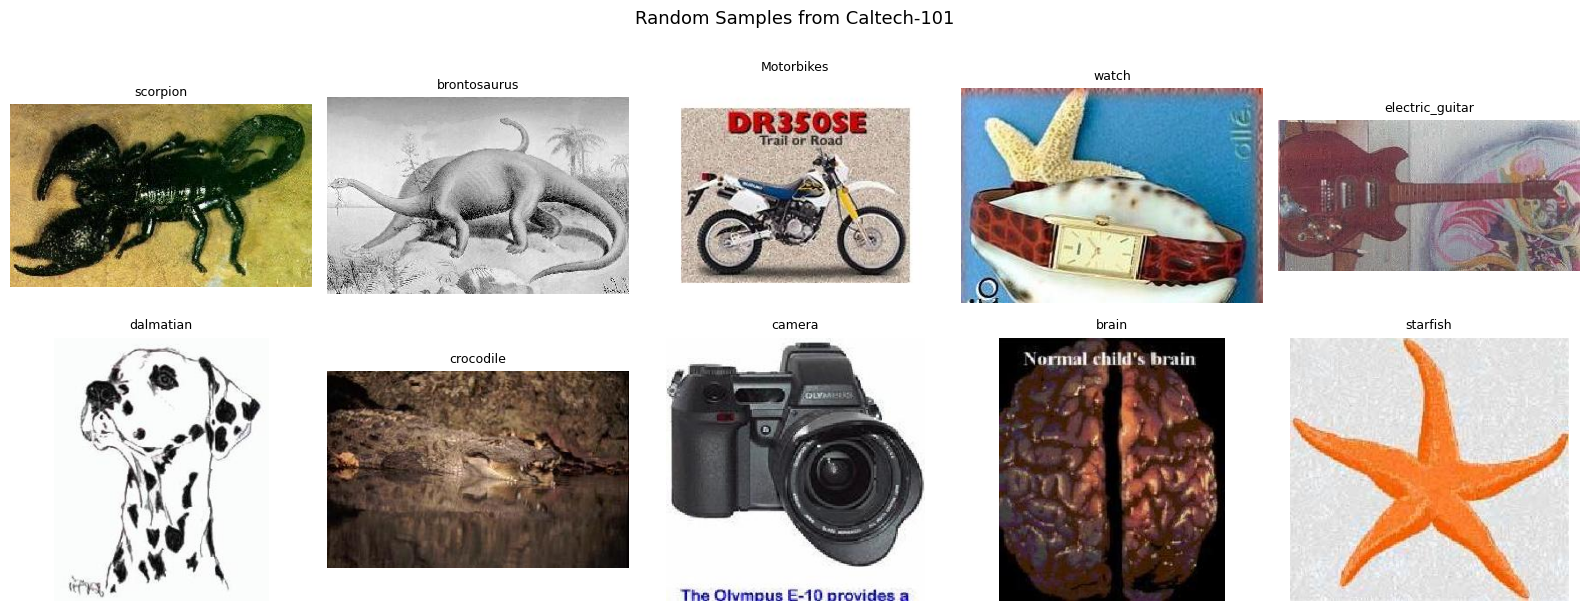

In [6]:
sample_classes = random.sample(class_names, 10)

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for i, cls in enumerate(sample_classes):
    # collect all image paths for this class
    candidates = []
    for p, l in zip(all_paths, all_labels):
        if l == cls:
            candidates.append(p)
    
    img = Image.open(random.choice(candidates)).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=9)
    axes[i].axis("off")

plt.suptitle("Random Samples from Caltech-101", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig_s1_samples.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 2 — Method 1: HOG + SVM (Classical ML Baseline)

The resulting feature vector of HOG is fed into an SVM with RBF kernel for classification.
This serves as the classical ML baseline to compare against deep learning methods.

In [7]:
def extract_hog(img_path, size=HOG_SIZE):
    img = Image.open(img_path).convert("L")  # grayscale
    img = img.resize((size, size))
    img_arr = np.array(img)
    features, _ = hog(
        img_arr,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=True
    )
    return features

def build_hog_dataset(paths, labels, desc="Extracting HOG"):
    X, y = [], []
    for i in tqdm(range(len(paths)), desc=desc):
        feat = extract_hog(paths[i])
        X.append(feat)
        y.append(labels[i])
    return np.array(X), np.array(y)


print("Extracting HOG features")
X_train_hog, y_train_hog = build_hog_dataset(train_paths, train_labels, "Train")
X_val_hog,   y_val_hog   = build_hog_dataset(val_paths,   val_labels,   "Val")
X_test_hog,  y_test_hog  = build_hog_dataset(test_paths,  test_labels,  "Test")

print(f"HOG feature vector dim: {X_train_hog.shape[1]}")

Extracting HOG features


Test: 100%|██████████| 1302/1302 [00:46<00:00, 28.16it/s]


HOG feature vector dim: 8100


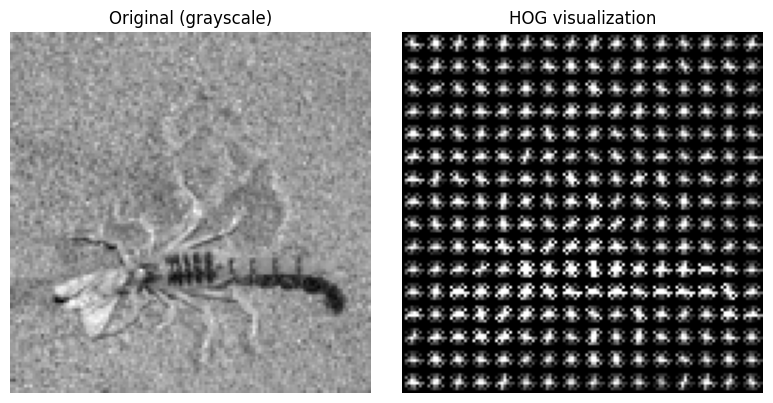

In [8]:
sample_path = train_paths[0]
sample_gray = np.array(Image.open(sample_path).convert("L").resize((HOG_SIZE, HOG_SIZE)))

_, hog_image = hog(
    sample_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True
)
hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_gray, cmap="gray")
axes[0].set_title("Original (grayscale)")
axes[0].axis("off")
axes[1].imshow(hog_image, cmap="gray")
axes[1].set_title("HOG visualization")
axes[1].axis("off")

plt.tight_layout()
plt.savefig("fig_s2_hog_vis.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Train SVM
# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)
X_val_scaled   = scaler.transform(X_val_hog)
X_test_scaled  = scaler.transform(X_test_hog)

print("Training SVM (C=10, kernel=rbf)")
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_train_scaled, y_train_hog)
print("Done")

Training SVM (C=10, kernel=rbf)
Done


In [63]:
y_pred = svm.predict(X_test_scaled)

acc = accuracy_score(y_test_hog, y_pred)
report = classification_report(y_test_hog, y_pred, target_names=class_names, output_dict=True)

print(f"Test Accuracy      : {acc*100:.2f}%")
print(f"Macro Precision    : {report['macro avg']['precision']:.4f}")
print(f"Macro Recall       : {report['macro avg']['recall']:.4f}")
print(f"Macro F1           : {report['macro avg']['f1-score']:.4f}")
print(f"Weighted Precision : {report['weighted avg']['precision']:.4f}")
print(f"Weighted Recall    : {report['weighted avg']['recall']:.4f}")
print(f"Weighted F1        : {report['weighted avg']['f1-score']:.4f}")

Test Accuracy      : 63.13%
Macro Precision    : 0.6230
Macro Recall       : 0.4336
Macro F1           : 0.4615
Weighted Precision : 0.6668
Weighted Recall    : 0.6313
Weighted F1        : 0.6045


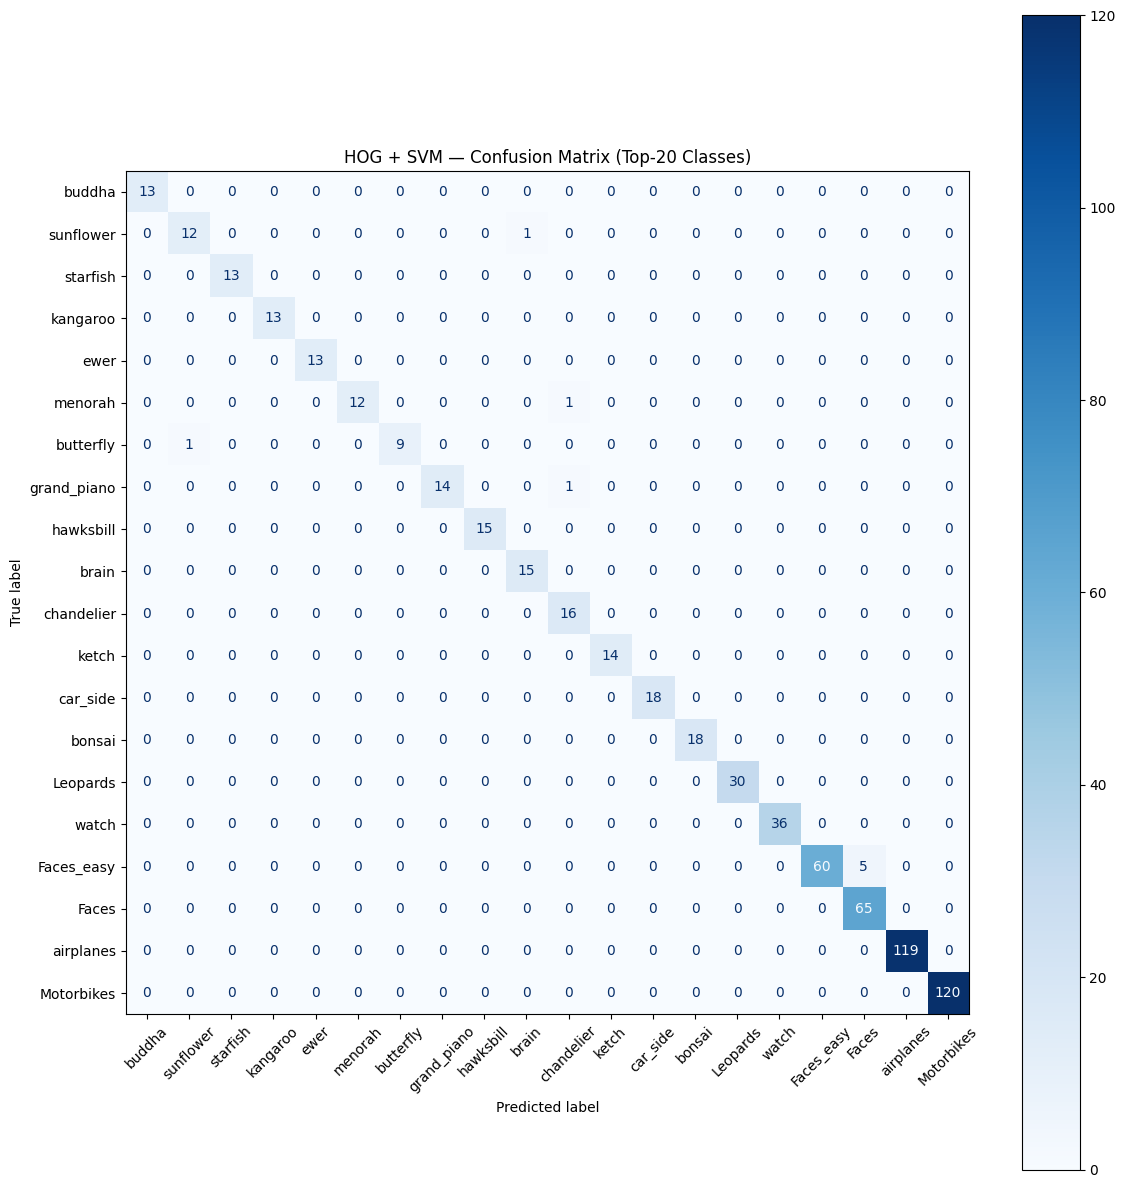

In [68]:
cm = confusion_matrix(y_test_hog, y_pred)

# Select top-20 classes by number of test samples
class_counts = np.bincount(y_test_hog)
top20_idx = np.argsort(class_counts)[-20:]
top20_names = [class_names[i] for i in top20_idx]
cm_top20 = cm[np.ix_(top20_idx, top20_idx)]

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_top20, display_labels=top20_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("HOG + SVM — Confusion Matrix (Top-20 Classes)")

plt.tight_layout()
plt.savefig("fig_s2_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

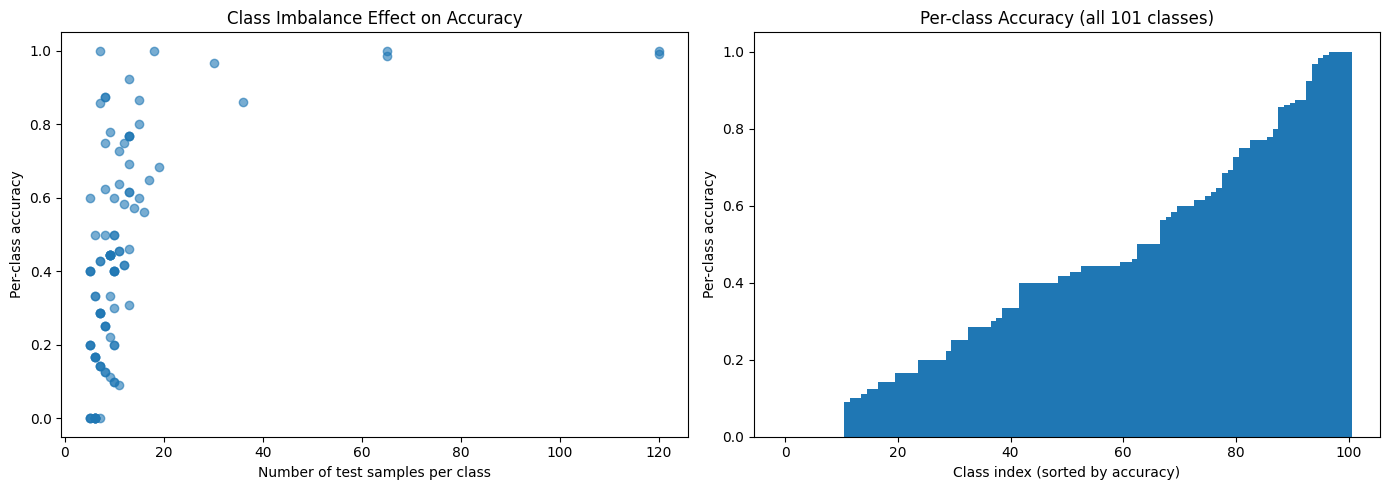

In [13]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
class_sample_counts = cm.sum(axis=1)  # number of test samples per class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter plot — sample count vs accuracy (shows imbalance effect)
axes[0].scatter(class_sample_counts, per_class_acc, alpha=0.6)
axes[0].set_xlabel("Number of test samples per class")
axes[0].set_ylabel("Per-class accuracy")
axes[0].set_title("Class Imbalance Effect on Accuracy")

# Right: bar chart of all classes sorted by accuracy
sorted_idx = np.argsort(per_class_acc)
axes[1].bar(range(len(sorted_idx)), per_class_acc[sorted_idx], width=1.0)
axes[1].set_xlabel("Class index (sorted by accuracy)")
axes[1].set_ylabel("Per-class accuracy")
axes[1].set_title("Per-class Accuracy (all 101 classes)")

plt.tight_layout()
plt.savefig("fig_s2_perclass_acc.png", dpi=150, bbox_inches="tight")
plt.show()

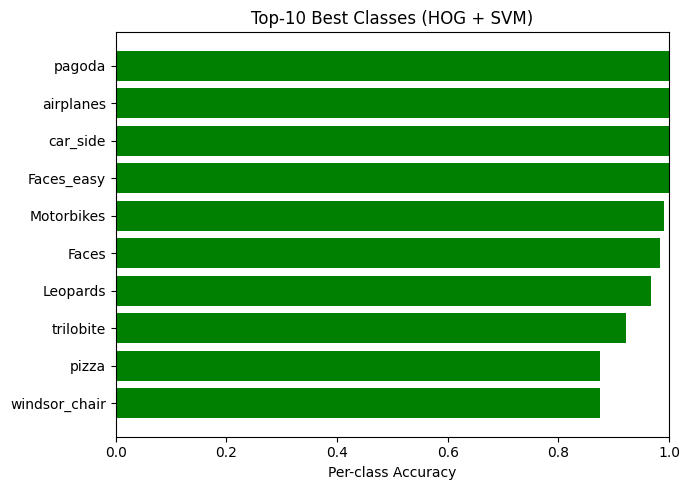

In [14]:
best10_idx   = np.argsort(per_class_acc)[-10:]
best10_names = [class_names[i] for i in best10_idx]
best10_acc   = [per_class_acc[i] for i in best10_idx]

plt.figure(figsize=(7, 5))
plt.barh(best10_names, best10_acc, color="green")
plt.xlim(0, 1)
plt.xlabel("Per-class Accuracy")
plt.title("Top-10 Best Classes (HOG + SVM)")
plt.tight_layout()
plt.savefig("fig_s2_top10.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 3 — Method 2: ResNet-50

ResNet-50 is a 50-layer CNN using skip connections to prevent gradient vanishing.
Pretrained on ImageNet, we freeze the backbone and only train the final classifier head.

In [15]:
class Caltech101Dataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


def make_loaders(img_size=IMG_SIZE, augment=True):
    if augment:
        train_tf = transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        train_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    val_test_tf = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    train_loader = DataLoader(
        Caltech101Dataset(train_paths, train_labels, train_tf),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
    )
    val_loader = DataLoader(
        Caltech101Dataset(val_paths, val_labels, val_test_tf),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
    )
    test_loader = DataLoader(
        Caltech101Dataset(test_paths, test_labels, val_test_tf),
        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
    )
    return train_loader, val_loader, test_loader

In [16]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), correct / total


def get_all_preds(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_labels), np.array(all_preds)

In [17]:
# build the ResNet model
def build_resnet(num_classes=NUM_CLASSES):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    # Freeze all backbone layers
    for param in model.parameters():
        param.requires_grad = False
    # Replace final FC layer — only this will be trained
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)


resnet = build_resnet()
print(resnet.fc)

Linear(in_features=2048, out_features=101, bias=True)


In [18]:
train_loader, val_loader, test_loader = make_loaders(img_size=IMG_SIZE, augment=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.fc.parameters(), lr=LR)

# Early stopping setup
best_val_loss = float("inf")
patience, patience_counter = 5, 0
best_weights = None

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(resnet, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(resnet, val_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS}  "
          f"train loss: {tr_loss:.4f}  acc: {tr_acc:.4f}  |  "
          f"val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

    # Early stopping: save best model, stop if no improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = resnet.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Restore best model weights
resnet.load_state_dict(best_weights)
print("Restored best model weights.")

Epoch  1/15  train loss: 3.4714  acc: 0.2539  |  val loss: 2.5522  acc: 0.4516
Epoch  2/15  train loss: 2.0872  acc: 0.6341  |  val loss: 1.5981  acc: 0.7765
Epoch  3/15  train loss: 1.3875  acc: 0.8273  |  val loss: 1.1163  acc: 0.8541
Epoch  4/15  train loss: 0.9884  acc: 0.8928  |  val loss: 0.8593  acc: 0.8871
Epoch  5/15  train loss: 0.7586  acc: 0.9211  |  val loss: 0.6799  acc: 0.9078
Epoch  6/15  train loss: 0.6060  acc: 0.9391  |  val loss: 0.5915  acc: 0.9109
Epoch  7/15  train loss: 0.5115  acc: 0.9442  |  val loss: 0.5093  acc: 0.9209
Epoch  8/15  train loss: 0.4275  acc: 0.9536  |  val loss: 0.4575  acc: 0.9201
Epoch  9/15  train loss: 0.3807  acc: 0.9534  |  val loss: 0.4215  acc: 0.9270
Epoch 10/15  train loss: 0.3374  acc: 0.9628  |  val loss: 0.3924  acc: 0.9263
Epoch 11/15  train loss: 0.3015  acc: 0.9661  |  val loss: 0.3731  acc: 0.9240
Epoch 12/15  train loss: 0.2785  acc: 0.9646  |  val loss: 0.3478  acc: 0.9293
Epoch 13/15  train loss: 0.2504  acc: 0.9684  |  val

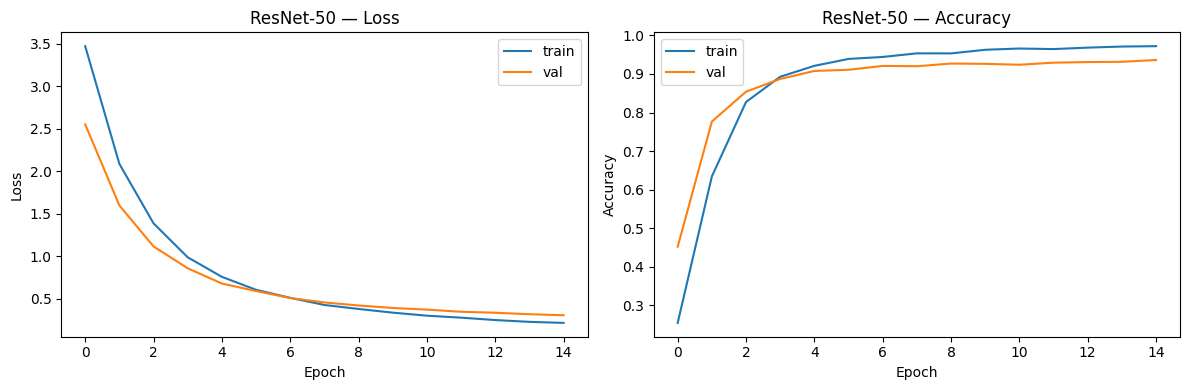

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses,   label="val")
axes[0].set_title("ResNet-50 — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs,   label="val")
axes[1].set_title("ResNet-50 — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_s3_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [64]:
y_true, y_pred = get_all_preds(resnet, test_loader)

acc    = accuracy_score(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

print(f"Test Accuracy      : {acc*100:.2f}%")
print(f"Macro Precision    : {report['macro avg']['precision']:.4f}")
print(f"Macro Recall       : {report['macro avg']['recall']:.4f}")
print(f"Macro F1           : {report['macro avg']['f1-score']:.4f}")
print(f"Weighted Precision : {report['weighted avg']['precision']:.4f}")
print(f"Weighted Recall    : {report['weighted avg']['recall']:.4f}")
print(f"Weighted F1        : {report['weighted avg']['f1-score']:.4f}")

Test Accuracy      : 91.94%
Macro Precision    : 0.9057
Macro Recall       : 0.8791
Macro F1           : 0.8838
Weighted Precision : 0.9260
Weighted Recall    : 0.9194
Weighted F1        : 0.9171


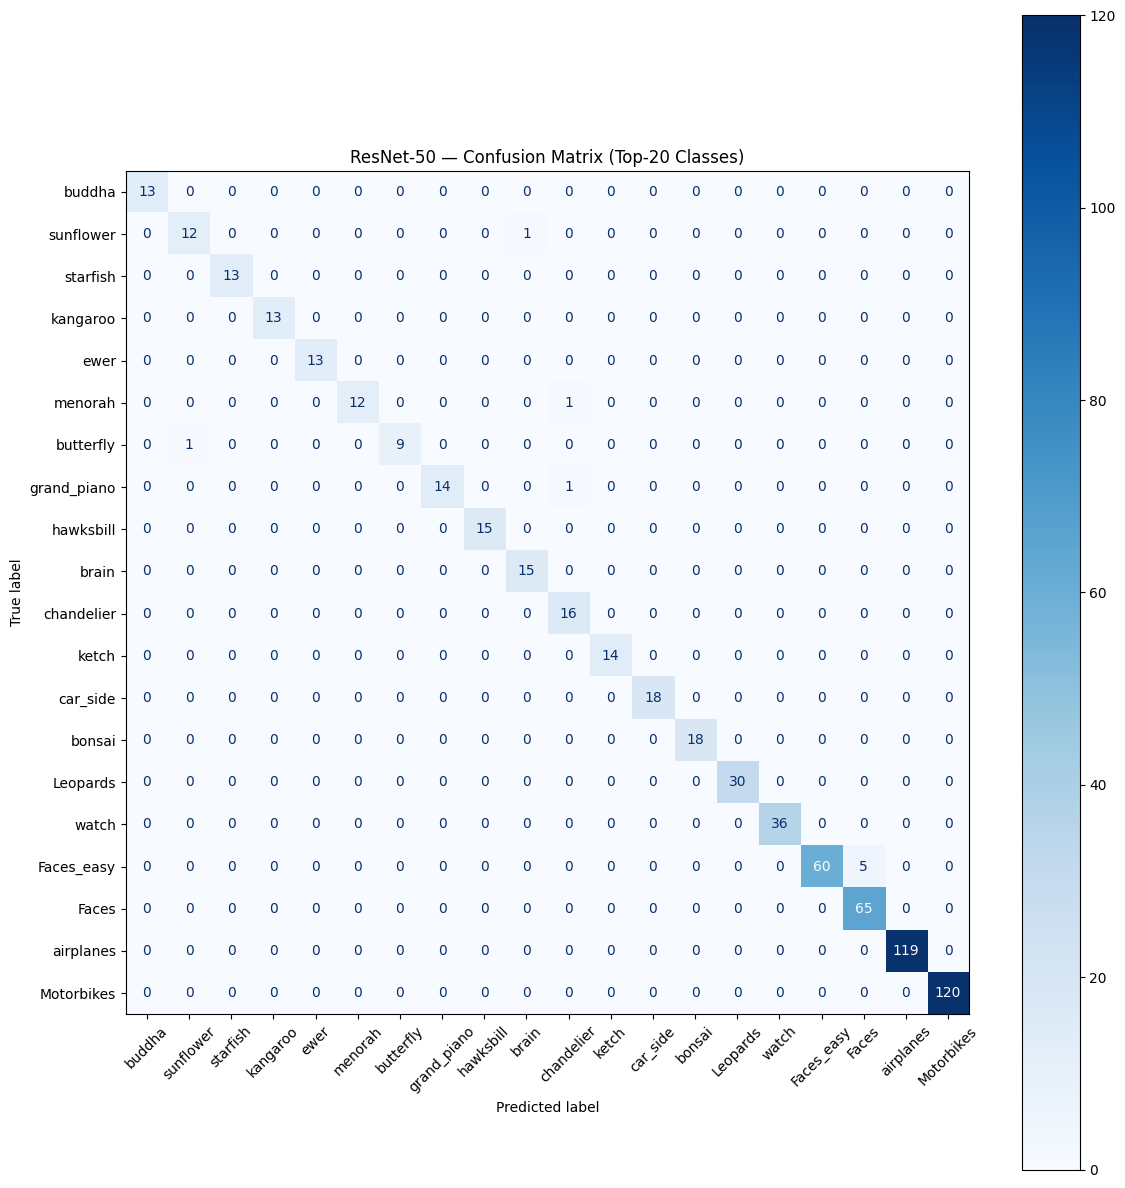

In [62]:
cm_resnet = confusion_matrix(y_true, y_pred)

class_counts = np.bincount(y_true)
top20_idx    = np.argsort(class_counts)[-20:]
top20_names  = [class_names[i] for i in top20_idx]
cm_top20     = cm_resnet[np.ix_(top20_idx, top20_idx)]

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_top20, display_labels=top20_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("ResNet-50 — Confusion Matrix (Top-20 Classes)")

plt.tight_layout()
plt.savefig("fig_s3_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

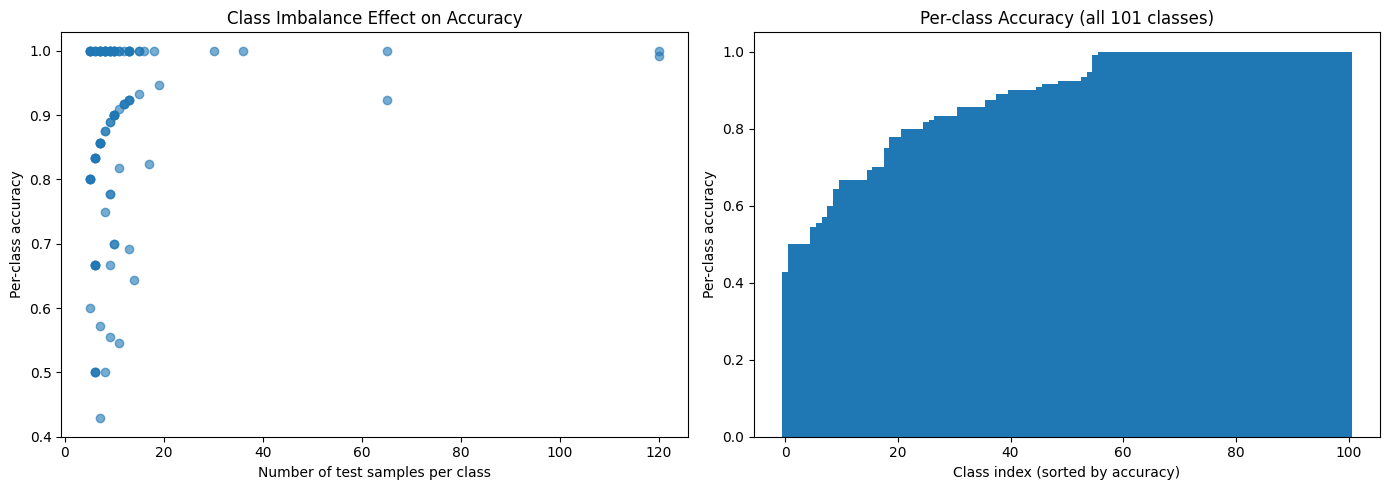

In [25]:
per_class_acc_resnet = cm_resnet.diagonal() / cm_resnet.sum(axis=1)
class_sample_counts  = cm_resnet.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(class_sample_counts, per_class_acc_resnet, alpha=0.6)
axes[0].set_xlabel("Number of test samples per class")
axes[0].set_ylabel("Per-class accuracy")
axes[0].set_title("Class Imbalance Effect on Accuracy")

sorted_idx = np.argsort(per_class_acc_resnet)
axes[1].bar(range(len(sorted_idx)), per_class_acc_resnet[sorted_idx], width=1.0)
axes[1].set_xlabel("Class index (sorted by accuracy)")
axes[1].set_ylabel("Per-class accuracy")
axes[1].set_title("Per-class Accuracy (all 101 classes)")

plt.tight_layout()
plt.savefig("fig_s3_perclass_acc.png", dpi=150, bbox_inches="tight")
plt.show()

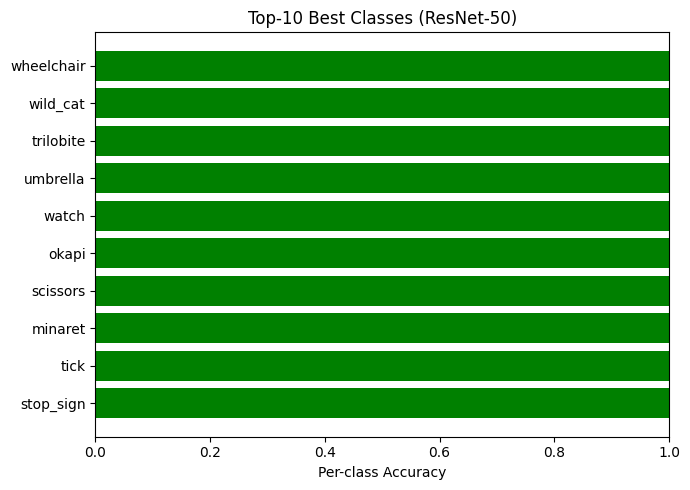

In [26]:
best10_idx   = np.argsort(per_class_acc_resnet)[-10:]
best10_names = [class_names[i] for i in best10_idx]
best10_acc   = [per_class_acc_resnet[i] for i in best10_idx]

plt.figure(figsize=(7, 5))
plt.barh(best10_names, best10_acc, color="green")
plt.xlim(0, 1)
plt.xlabel("Per-class Accuracy")
plt.title("Top-10 Best Classes (ResNet-50)")
plt.tight_layout()
plt.savefig("fig_s3_top10.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 4 — Method 3: EfficientNet-B0

In [ ]:
def build_efficientnet(num_classes=NUM_CLASSES):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(device)

effnet = build_efficientnet()
print(effnet.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\anaki/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 11.1MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=101, bias=True)
)


In [28]:
train_loader, val_loader, test_loader = make_loaders(img_size=IMG_SIZE, augment=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(effnet.classifier.parameters(), lr=LR)

best_val_loss = float("inf")
patience, patience_counter = 5, 0
best_weights = None

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc   = train_one_epoch(effnet, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(effnet, val_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS}  "
          f"train loss: {tr_loss:.4f}  acc: {tr_acc:.4f}  |  "
          f"val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = effnet.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

effnet.load_state_dict(best_weights)
print("Restored best model weights.")

Epoch  1/15  train loss: 3.9668  acc: 0.2933  |  val loss: 3.4284  acc: 0.5230
Epoch  2/15  train loss: 2.9692  acc: 0.5113  |  val loss: 2.6674  acc: 0.6536
Epoch  3/15  train loss: 2.3418  acc: 0.6652  |  val loss: 2.1666  acc: 0.7488
Epoch  4/15  train loss: 1.9026  acc: 0.7630  |  val loss: 1.8122  acc: 0.8034
Epoch  5/15  train loss: 1.5639  acc: 0.8227  |  val loss: 1.5087  acc: 0.8402
Epoch  6/15  train loss: 1.3118  acc: 0.8617  |  val loss: 1.2723  acc: 0.8602
Epoch  7/15  train loss: 1.1150  acc: 0.8806  |  val loss: 1.1054  acc: 0.8779
Epoch  8/15  train loss: 0.9559  acc: 0.8994  |  val loss: 0.9530  acc: 0.8902
Epoch  9/15  train loss: 0.8332  acc: 0.9083  |  val loss: 0.8748  acc: 0.8925
Epoch 10/15  train loss: 0.7491  acc: 0.9160  |  val loss: 0.7861  acc: 0.8879
Epoch 11/15  train loss: 0.6633  acc: 0.9243  |  val loss: 0.7283  acc: 0.8925
Epoch 12/15  train loss: 0.6047  acc: 0.9307  |  val loss: 0.6683  acc: 0.9002
Epoch 13/15  train loss: 0.5596  acc: 0.9285  |  val

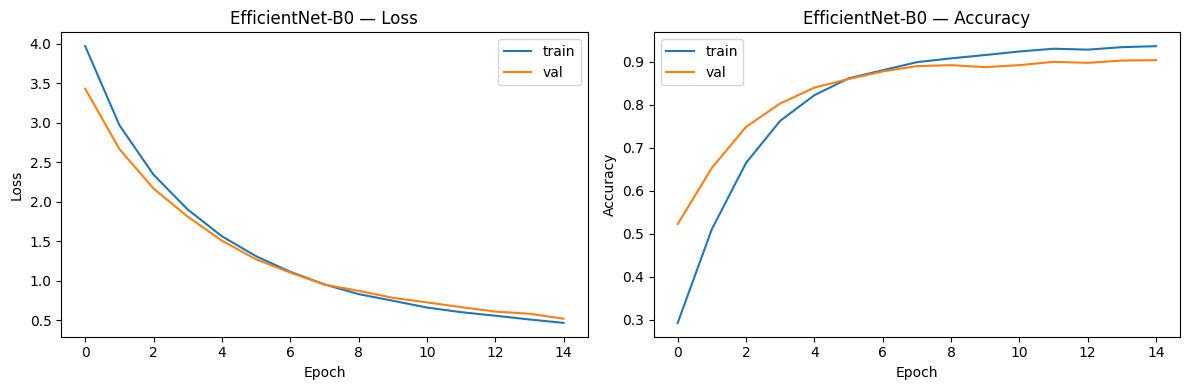

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses,   label="val")
axes[0].set_title("EfficientNet-B0 — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs,   label="val")
axes[1].set_title("EfficientNet-B0 — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_s4_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [65]:
y_true_eff, y_pred_eff = get_all_preds(effnet, test_loader)

acc    = accuracy_score(y_true_eff, y_pred_eff)
report = classification_report(y_true_eff, y_pred_eff, target_names=class_names, output_dict=True)

print(f"Test Accuracy      : {acc*100:.2f}%")
print(f"Macro Precision    : {report['macro avg']['precision']:.4f}")
print(f"Macro Recall       : {report['macro avg']['recall']:.4f}")
print(f"Macro F1           : {report['macro avg']['f1-score']:.4f}")
print(f"Weighted Precision : {report['weighted avg']['precision']:.4f}")
print(f"Weighted Recall    : {report['weighted avg']['recall']:.4f}")
print(f"Weighted F1        : {report['weighted avg']['f1-score']:.4f}")

Test Accuracy      : 91.09%
Macro Precision    : 0.9029
Macro Recall       : 0.8720
Macro F1           : 0.8780
Weighted Precision : 0.9168
Weighted Recall    : 0.9109
Weighted F1        : 0.9076


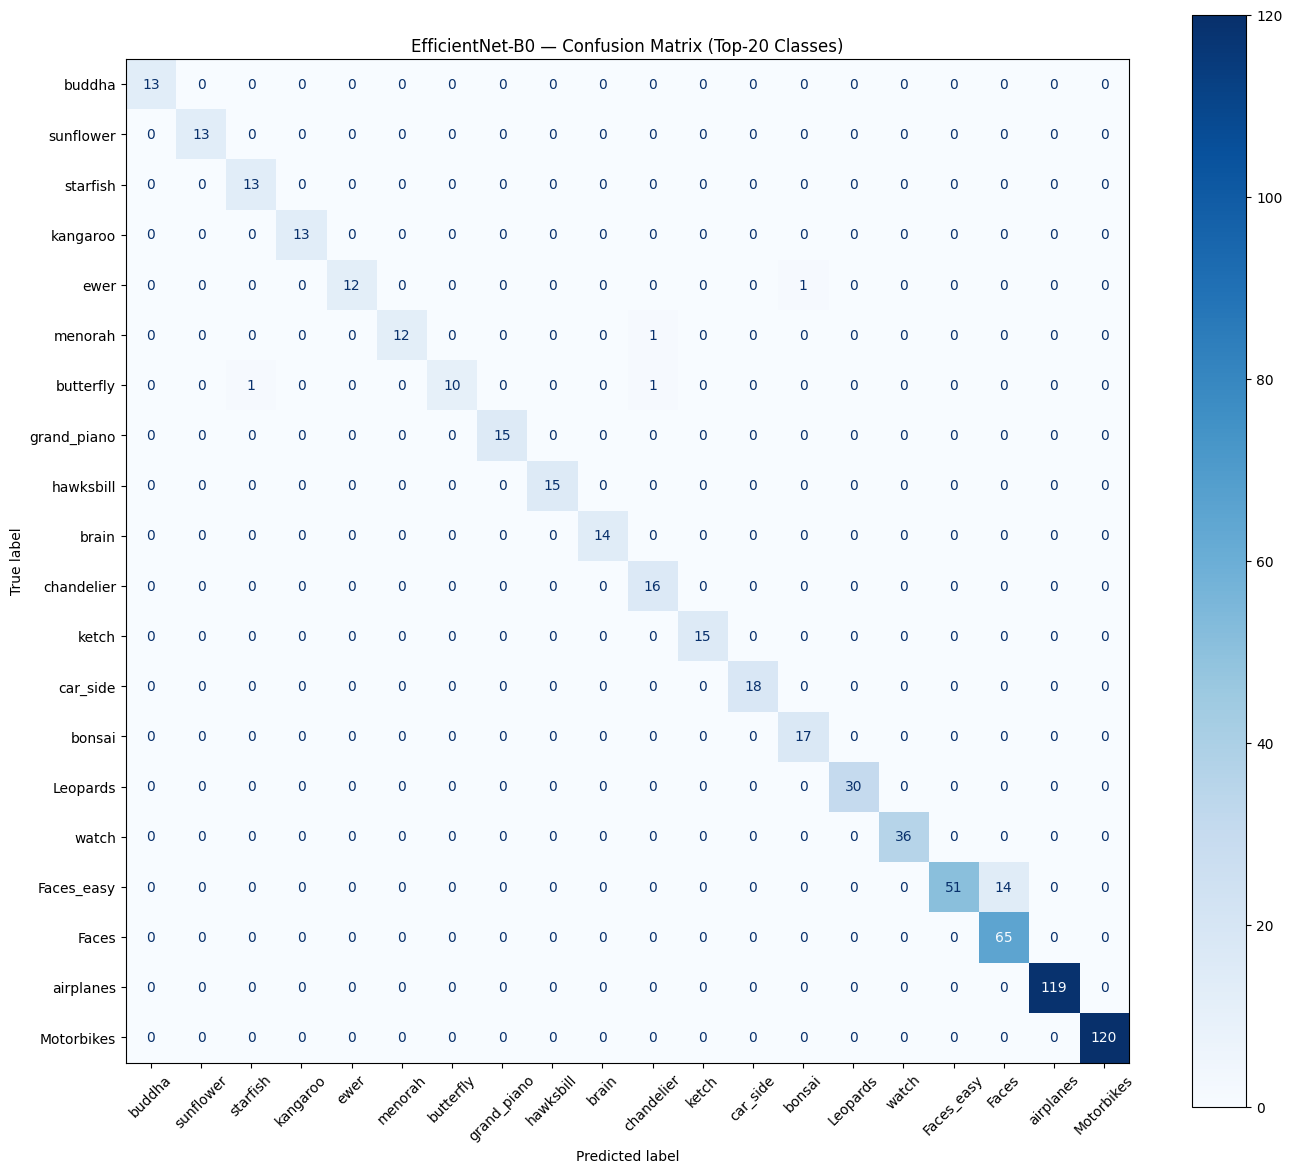

In [31]:
cm_effnet = confusion_matrix(y_true_eff, y_pred_eff)

class_counts = np.bincount(y_true_eff)
top20_idx    = np.argsort(class_counts)[-20:]
top20_names  = [class_names[i] for i in top20_idx]
cm_top20     = cm_effnet[np.ix_(top20_idx, top20_idx)]

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_top20, display_labels=top20_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("EfficientNet-B0 — Confusion Matrix (Top-20 Classes)")

plt.tight_layout()
plt.savefig("fig_s4_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

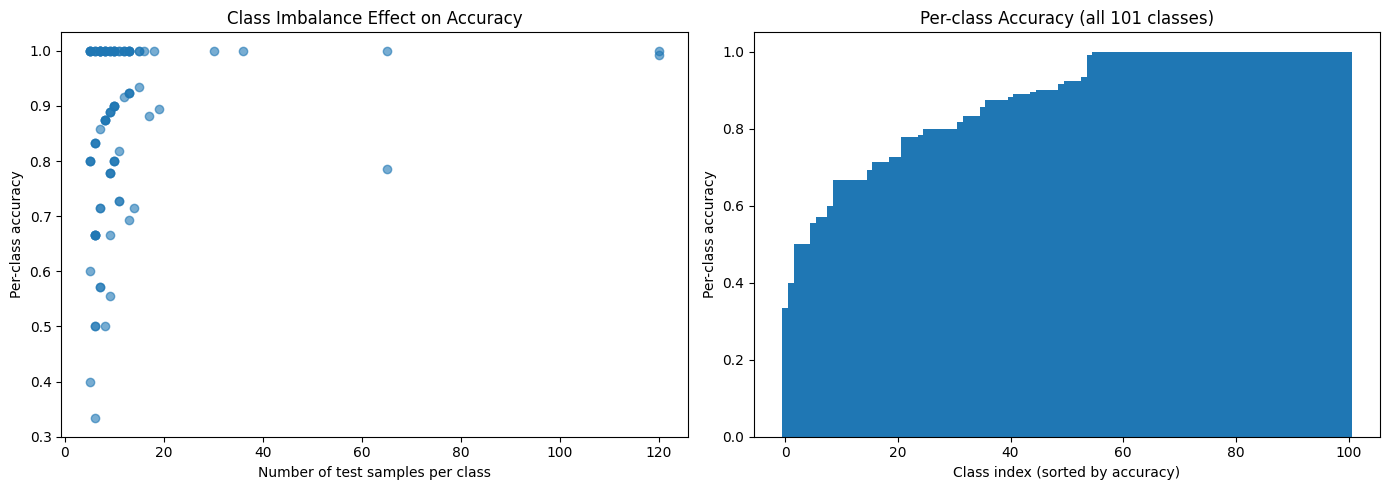

In [32]:
per_class_acc_eff = cm_effnet.diagonal() / cm_effnet.sum(axis=1)
class_sample_counts = cm_effnet.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(class_sample_counts, per_class_acc_eff, alpha=0.6)
axes[0].set_xlabel("Number of test samples per class")
axes[0].set_ylabel("Per-class accuracy")
axes[0].set_title("Class Imbalance Effect on Accuracy")

sorted_idx = np.argsort(per_class_acc_eff)
axes[1].bar(range(len(sorted_idx)), per_class_acc_eff[sorted_idx], width=1.0)
axes[1].set_xlabel("Class index (sorted by accuracy)")
axes[1].set_ylabel("Per-class accuracy")
axes[1].set_title("Per-class Accuracy (all 101 classes)")

plt.tight_layout()
plt.savefig("fig_s4_perclass_acc.png", dpi=150, bbox_inches="tight")
plt.show()

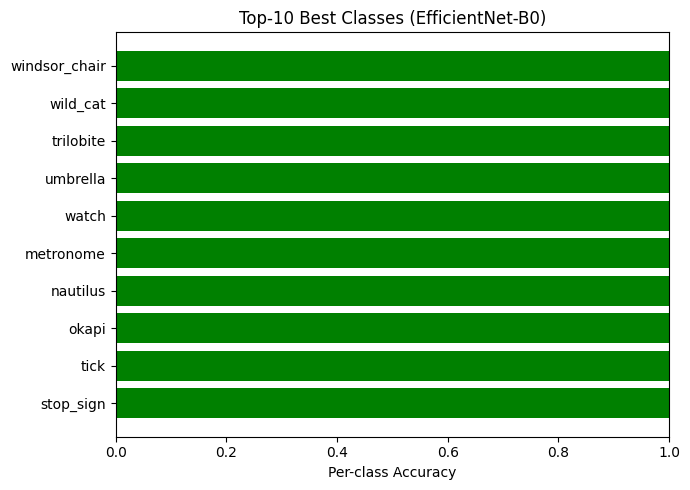

In [33]:
best10_idx   = np.argsort(per_class_acc_eff)[-10:]
best10_names = [class_names[i] for i in best10_idx]
best10_acc   = [per_class_acc_eff[i] for i in best10_idx]

plt.figure(figsize=(7, 5))
plt.barh(best10_names, best10_acc, color="green")
plt.xlim(0, 1)
plt.xlabel("Per-class Accuracy")
plt.title("Top-10 Best Classes (EfficientNet-B0)")
plt.tight_layout()
plt.savefig("fig_s4_top10.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 5 — Method 4: ViT-Small

In [34]:
def build_vit(num_classes=NUM_CLASSES):
    model = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=num_classes)
    # Freeze all layers except the classifier head
    for name, param in model.named_parameters():
        if "head" not in name:
            param.requires_grad = False
    return model.to(device)

vit = build_vit()
print(vit.head)

Linear(in_features=384, out_features=101, bias=True)


In [35]:
train_loader, val_loader, test_loader = make_loaders(img_size=IMG_SIZE, augment=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vit.head.parameters(), lr=LR)

best_val_loss = float("inf")
patience, patience_counter = 5, 0
best_weights = None

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc   = train_one_epoch(vit, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(vit, val_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS}  "
          f"train loss: {tr_loss:.4f}  acc: {tr_acc:.4f}  |  "
          f"val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = vit.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

vit.load_state_dict(best_weights)
print("Restored best model weights.")

Epoch  1/15  train loss: 3.1753  acc: 0.3562  |  val loss: 1.9551  acc: 0.6344
Epoch  2/15  train loss: 1.3397  acc: 0.7886  |  val loss: 1.0127  acc: 0.8610
Epoch  3/15  train loss: 0.7235  acc: 0.8974  |  val loss: 0.6531  acc: 0.9025
Epoch  4/15  train loss: 0.4744  acc: 0.9289  |  val loss: 0.4943  acc: 0.9217
Epoch  5/15  train loss: 0.3662  acc: 0.9417  |  val loss: 0.4091  acc: 0.9332
Epoch  6/15  train loss: 0.2869  acc: 0.9554  |  val loss: 0.3574  acc: 0.9339
Epoch  7/15  train loss: 0.2512  acc: 0.9597  |  val loss: 0.3188  acc: 0.9370
Epoch  8/15  train loss: 0.2072  acc: 0.9656  |  val loss: 0.2930  acc: 0.9424
Epoch  9/15  train loss: 0.1850  acc: 0.9697  |  val loss: 0.2764  acc: 0.9416
Epoch 10/15  train loss: 0.1622  acc: 0.9735  |  val loss: 0.2576  acc: 0.9447
Epoch 11/15  train loss: 0.1468  acc: 0.9778  |  val loss: 0.2430  acc: 0.9501
Epoch 12/15  train loss: 0.1299  acc: 0.9756  |  val loss: 0.2336  acc: 0.9501
Epoch 13/15  train loss: 0.1262  acc: 0.9784  |  val

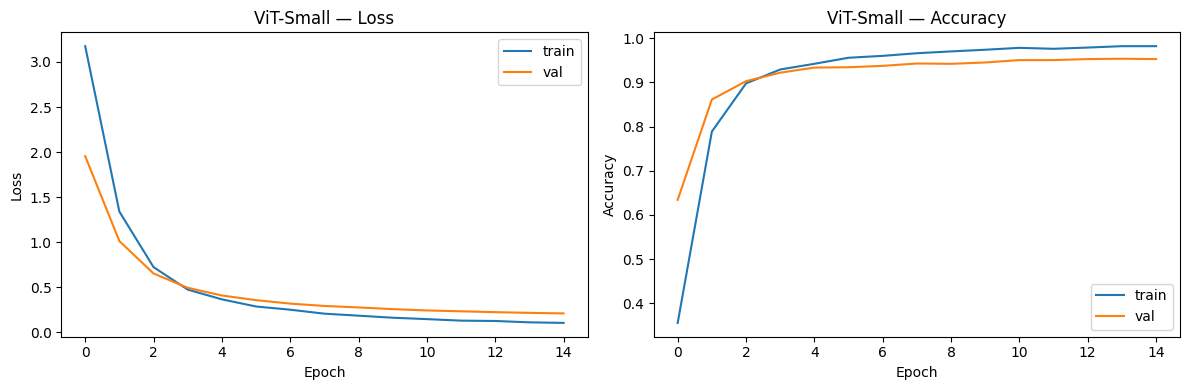

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses,   label="val")
axes[0].set_title("ViT-Small — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs,   label="val")
axes[1].set_title("ViT-Small — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_s5_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [66]:
y_true_vit, y_pred_vit = get_all_preds(vit, test_loader)

acc    = accuracy_score(y_true_vit, y_pred_vit)
report = classification_report(y_true_vit, y_pred_vit, target_names=class_names, output_dict=True)

print(f"Test Accuracy      : {acc*100:.2f}%")
print(f"Macro Precision    : {report['macro avg']['precision']:.4f}")
print(f"Macro Recall       : {report['macro avg']['recall']:.4f}")
print(f"Macro F1           : {report['macro avg']['f1-score']:.4f}")
print(f"Weighted Precision : {report['weighted avg']['precision']:.4f}")
print(f"Weighted Recall    : {report['weighted avg']['recall']:.4f}")
print(f"Weighted F1        : {report['weighted avg']['f1-score']:.4f}")

Test Accuracy      : 93.86%
Macro Precision    : 0.9202
Macro Recall       : 0.9086
Macro F1           : 0.9099
Weighted Precision : 0.9441
Weighted Recall    : 0.9386
Weighted F1        : 0.9388


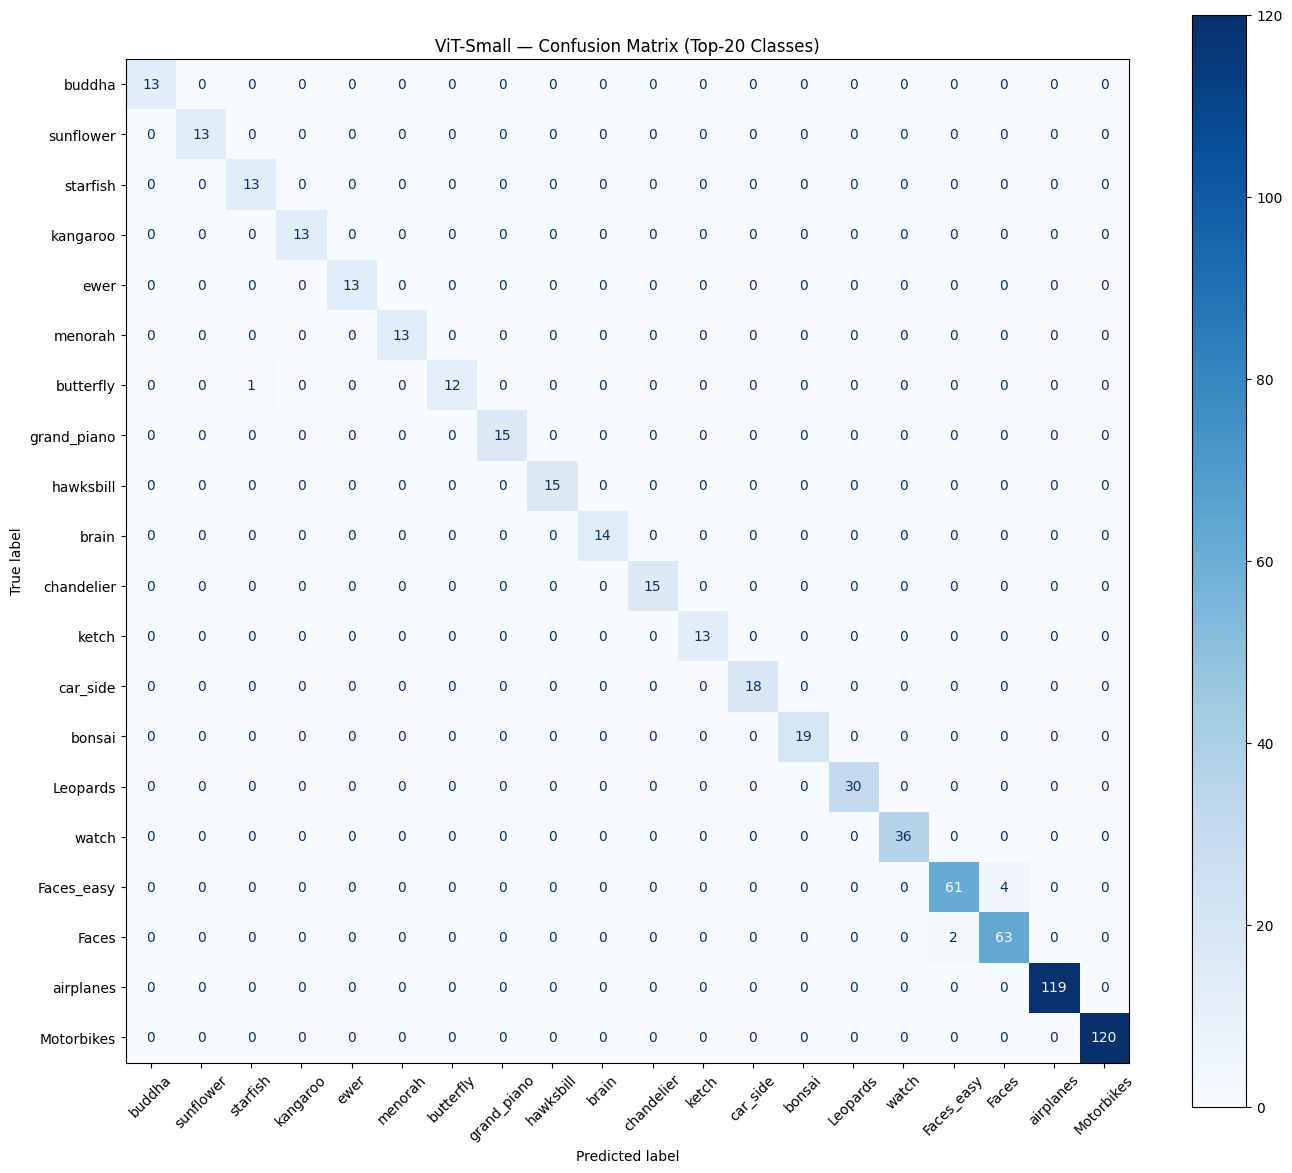

In [38]:
cm_vit = confusion_matrix(y_true_vit, y_pred_vit)

class_counts = np.bincount(y_true_vit)
top20_idx    = np.argsort(class_counts)[-20:]
top20_names  = [class_names[i] for i in top20_idx]
cm_top20     = cm_vit[np.ix_(top20_idx, top20_idx)]

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_top20, display_labels=top20_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("ViT-Small — Confusion Matrix (Top-20 Classes)")

plt.tight_layout()
plt.savefig("fig_s5_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

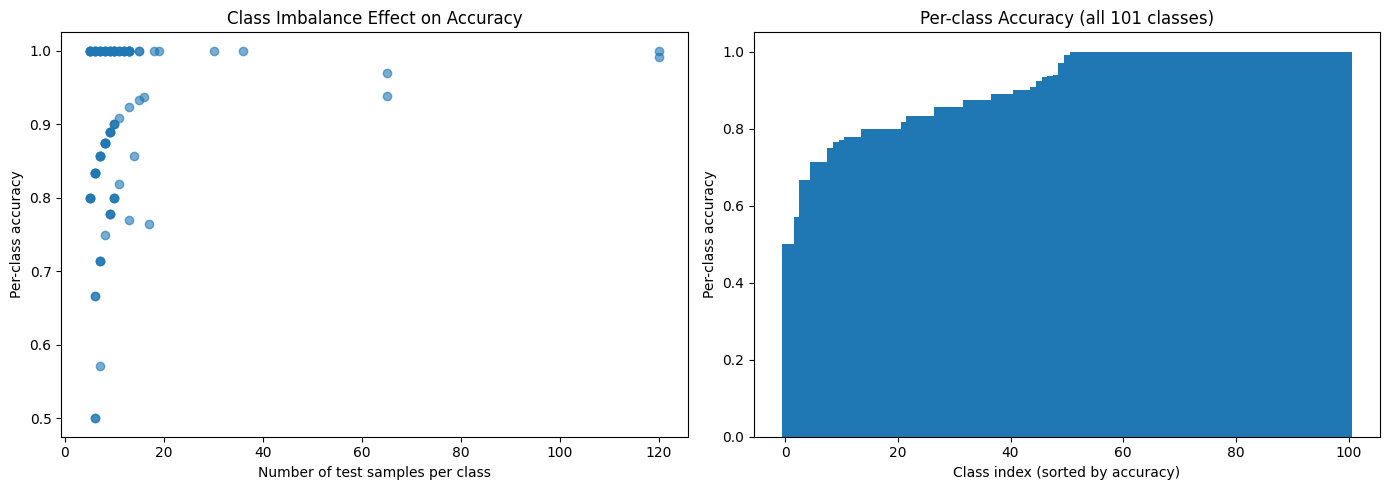

In [39]:
per_class_acc_vit = cm_vit.diagonal() / cm_vit.sum(axis=1)
class_sample_counts = cm_vit.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(class_sample_counts, per_class_acc_vit, alpha=0.6)
axes[0].set_xlabel("Number of test samples per class")
axes[0].set_ylabel("Per-class accuracy")
axes[0].set_title("Class Imbalance Effect on Accuracy")

sorted_idx = np.argsort(per_class_acc_vit)
axes[1].bar(range(len(sorted_idx)), per_class_acc_vit[sorted_idx], width=1.0)
axes[1].set_xlabel("Class index (sorted by accuracy)")
axes[1].set_ylabel("Per-class accuracy")
axes[1].set_title("Per-class Accuracy (all 101 classes)")

plt.tight_layout()
plt.savefig("fig_s5_perclass_acc.png", dpi=150, bbox_inches="tight")
plt.show()

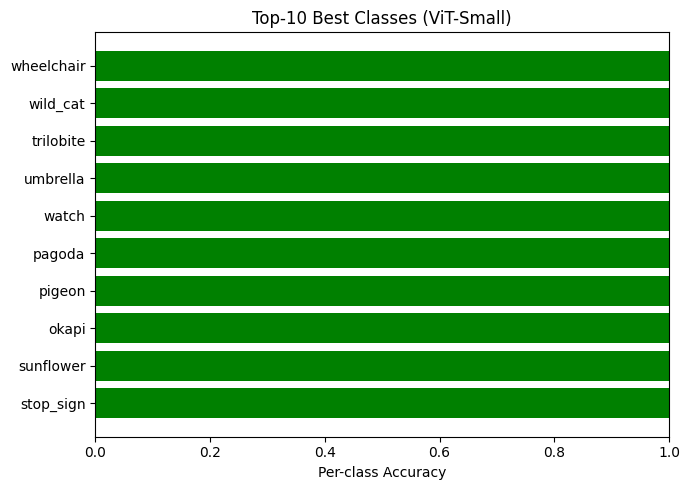

In [40]:
best10_idx   = np.argsort(per_class_acc_vit)[-10:]
best10_names = [class_names[i] for i in best10_idx]
best10_acc   = [per_class_acc_vit[i] for i in best10_idx]

plt.figure(figsize=(7, 5))
plt.barh(best10_names, best10_acc, color="green")
plt.xlim(0, 1)
plt.xlabel("Per-class Accuracy")
plt.title("Top-10 Best Classes (ViT-Small)")
plt.tight_layout()
plt.savefig("fig_s5_top10.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 6 — Method 5: ConvNeXt-Tiny

In [41]:
def build_convnext(num_classes=NUM_CLASSES):
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    # Replace classifier head
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model.to(device)

convnext = build_convnext()
print(convnext.classifier)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to C:\Users\anaki/.cache\torch\hub\checkpoints\convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:11<00:00, 10.1MB/s] 


Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=101, bias=True)
)


In [42]:
train_loader, val_loader, test_loader = make_loaders(img_size=IMG_SIZE, augment=True)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(convnext.classifier.parameters(), lr=LR)

best_val_loss = float("inf")
patience, patience_counter = 5, 0
best_weights = None

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    tr_loss, tr_acc   = train_one_epoch(convnext, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(convnext, val_loader, criterion)

    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    train_accs.append(tr_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS}  "
          f"train loss: {tr_loss:.4f}  acc: {tr_acc:.4f}  |  "
          f"val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = convnext.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

convnext.load_state_dict(best_weights)
print("Restored best model weights.")

Epoch  1/15  train loss: 3.9185  acc: 0.3871  |  val loss: 3.1659  acc: 0.6659
Epoch  2/15  train loss: 2.6477  acc: 0.7565  |  val loss: 2.1719  acc: 0.8141
Epoch  3/15  train loss: 1.8656  acc: 0.8561  |  val loss: 1.5728  acc: 0.8633
Epoch  4/15  train loss: 1.3571  acc: 0.8996  |  val loss: 1.1695  acc: 0.8902
Epoch  5/15  train loss: 1.0072  acc: 0.9211  |  val loss: 0.8998  acc: 0.9109
Epoch  6/15  train loss: 0.7660  acc: 0.9406  |  val loss: 0.7171  acc: 0.9194
Epoch  7/15  train loss: 0.6087  acc: 0.9486  |  val loss: 0.5934  acc: 0.9270
Epoch  8/15  train loss: 0.4965  acc: 0.9550  |  val loss: 0.5057  acc: 0.9363
Epoch  9/15  train loss: 0.4142  acc: 0.9648  |  val loss: 0.4423  acc: 0.9401
Epoch 10/15  train loss: 0.3533  acc: 0.9658  |  val loss: 0.3927  acc: 0.9424
Epoch 11/15  train loss: 0.3064  acc: 0.9690  |  val loss: 0.3567  acc: 0.9432
Epoch 12/15  train loss: 0.2717  acc: 0.9704  |  val loss: 0.3269  acc: 0.9447
Epoch 13/15  train loss: 0.2411  acc: 0.9740  |  val

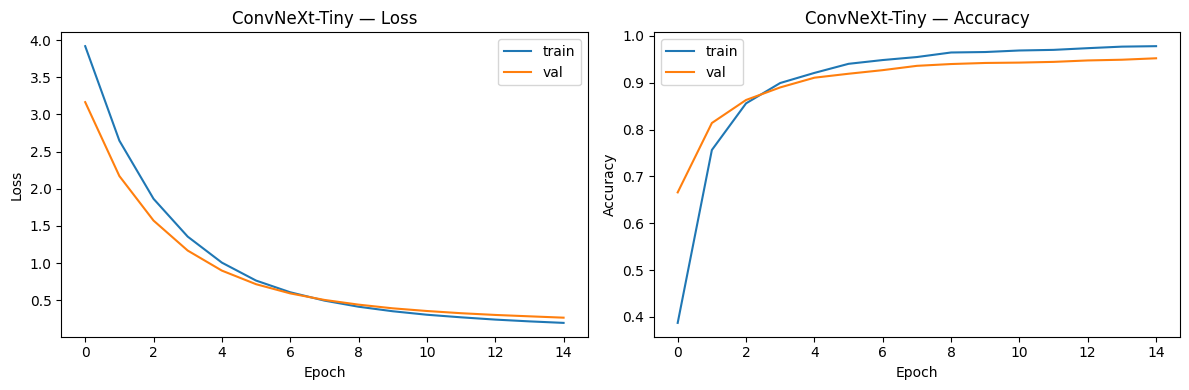

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="train")
axes[0].plot(val_losses,   label="val")
axes[0].set_title("ConvNeXt-Tiny — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(train_accs, label="train")
axes[1].plot(val_accs,   label="val")
axes[1].set_title("ConvNeXt-Tiny — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_s6_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [67]:
y_true_cvx, y_pred_cvx = get_all_preds(convnext, test_loader)

acc    = accuracy_score(y_true_cvx, y_pred_cvx)
report = classification_report(y_true_cvx, y_pred_cvx, target_names=class_names, output_dict=True)

print(f"Test Accuracy      : {acc*100:.2f}%")
print(f"Macro Precision    : {report['macro avg']['precision']:.4f}")
print(f"Macro Recall       : {report['macro avg']['recall']:.4f}")
print(f"Macro F1           : {report['macro avg']['f1-score']:.4f}")
print(f"Weighted Precision : {report['weighted avg']['precision']:.4f}")
print(f"Weighted Recall    : {report['weighted avg']['recall']:.4f}")
print(f"Weighted F1        : {report['weighted avg']['f1-score']:.4f}")

Test Accuracy      : 95.08%
Macro Precision    : 0.9368
Macro Recall       : 0.9214
Macro F1           : 0.9239
Weighted Precision : 0.9558
Weighted Recall    : 0.9508
Weighted F1        : 0.9504


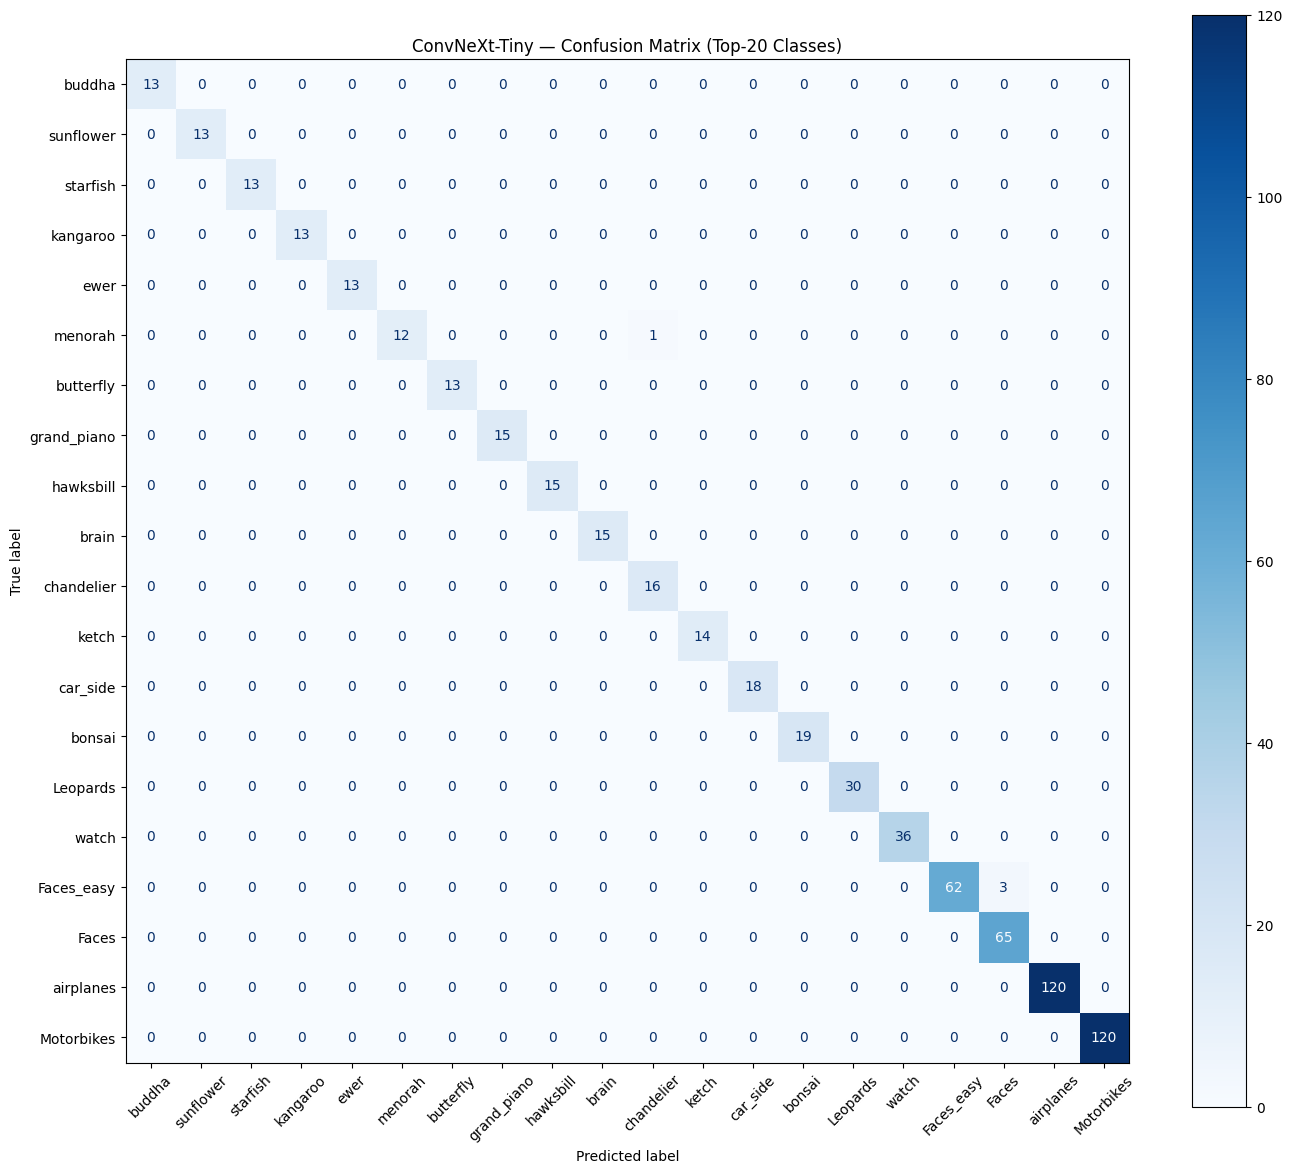

In [45]:
cm_cvx = confusion_matrix(y_true_cvx, y_pred_cvx)

class_counts = np.bincount(y_true_cvx)
top20_idx    = np.argsort(class_counts)[-20:]
top20_names  = [class_names[i] for i in top20_idx]
cm_top20     = cm_cvx[np.ix_(top20_idx, top20_idx)]

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_top20, display_labels=top20_names)
disp.plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=45)
ax.set_title("ConvNeXt-Tiny — Confusion Matrix (Top-20 Classes)")

plt.tight_layout()
plt.savefig("fig_s6_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

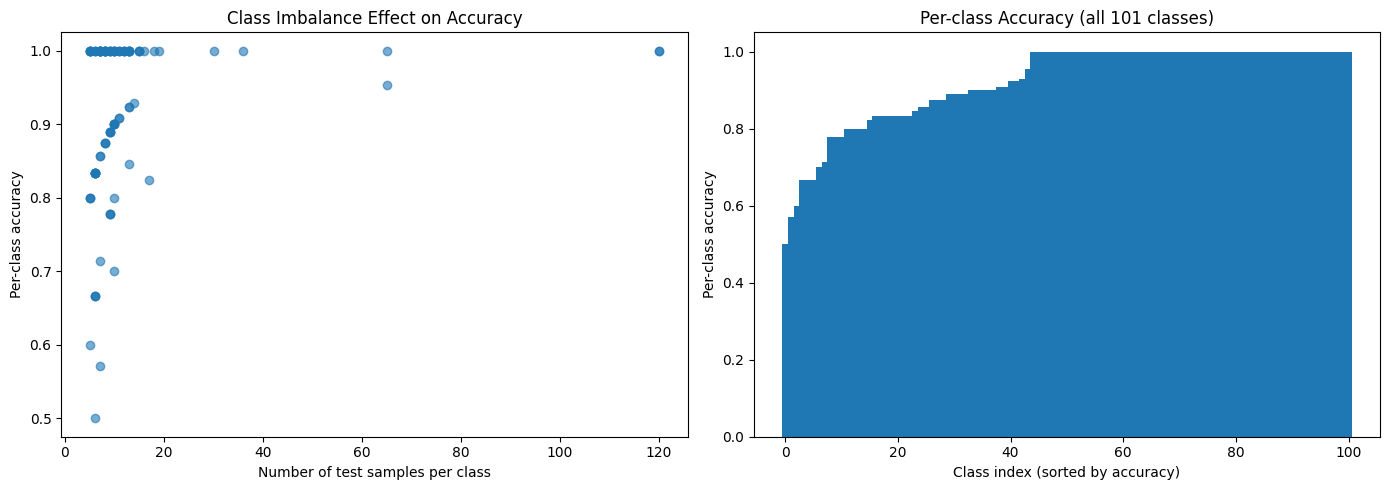

In [46]:
per_class_acc_cvx = cm_cvx.diagonal() / cm_cvx.sum(axis=1)
class_sample_counts = cm_cvx.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(class_sample_counts, per_class_acc_cvx, alpha=0.6)
axes[0].set_xlabel("Number of test samples per class")
axes[0].set_ylabel("Per-class accuracy")
axes[0].set_title("Class Imbalance Effect on Accuracy")

sorted_idx = np.argsort(per_class_acc_cvx)
axes[1].bar(range(len(sorted_idx)), per_class_acc_cvx[sorted_idx], width=1.0)
axes[1].set_xlabel("Class index (sorted by accuracy)")
axes[1].set_ylabel("Per-class accuracy")
axes[1].set_title("Per-class Accuracy (all 101 classes)")

plt.tight_layout()
plt.savefig("fig_s6_perclass_acc.png", dpi=150, bbox_inches="tight")
plt.show()

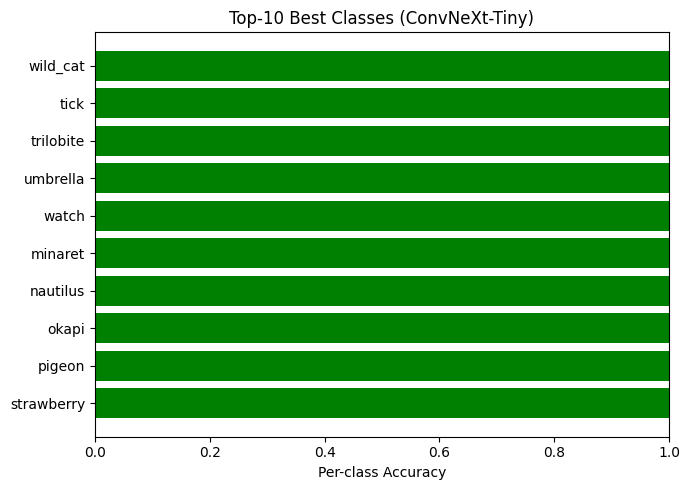

In [47]:
best10_idx   = np.argsort(per_class_acc_cvx)[-10:]
best10_names = [class_names[i] for i in best10_idx]
best10_acc   = [per_class_acc_cvx[i] for i in best10_idx]

plt.figure(figsize=(7, 5))
plt.barh(best10_names, best10_acc, color="green")
plt.xlim(0, 1)
plt.xlabel("Per-class Accuracy")
plt.title("Top-10 Best Classes (ConvNeXt-Tiny)")
plt.tight_layout()
plt.savefig("fig_s6_top10.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 7 — Ablation Studies

Three experiments using ResNet-50 as base model, changing one variable at a time:
- Experiment 1: Image size — 64 vs 128 vs 224
- Experiment 2: Data augmentation — with vs without
- Experiment 3: Optimizer — Adam vs SGD

In [48]:
def run_experiment(model_fn, train_loader, val_loader, test_loader, optimizer_fn, num_epochs=10):
    model = model_fn()
    criterion = nn.CrossEntropyLoss()
    optimizer = optimizer_fn(model)

    best_val_loss = float("inf")
    patience, patience_counter = 5, 0
    best_weights = None

    for epoch in range(num_epochs):
        train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, _ = evaluate(model, val_loader, criterion)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_weights)
    y_true, y_pred = get_all_preds(model, test_loader)
    return accuracy_score(y_true, y_pred)

In [49]:
results_imgsize = {}

for size in [64, 128, 224]:
    print(f"Training with image size {size}×{size}...")
    train_loader, val_loader, test_loader = make_loaders(img_size=size, augment=True)
    acc = run_experiment(
        model_fn=build_resnet,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        optimizer_fn=lambda m: optim.Adam(m.fc.parameters(), lr=LR)
    )
    results_imgsize[size] = acc
    print(f"  {size}×{size}: {acc*100:.2f}%")

Training with image size 64×64...
  64×64: 60.14%
Training with image size 128×128...
  128×128: 86.64%
Training with image size 224×224...
  224×224: 90.94%


In [51]:
results_aug = {}

for augment, label in [(False, "no aug"), (True, "with aug")]:
    print(f"Training {label}...")
    train_loader, val_loader, test_loader = make_loaders(img_size=IMG_SIZE, augment=augment)
    acc = run_experiment(
        model_fn=build_resnet,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        optimizer_fn=lambda m: optim.Adam(m.fc.parameters(), lr=LR)
    )
    results_aug[label] = acc
    print(f"  {label}: {acc*100:.2f}%")

Training no aug...
  no aug: 92.32%
Training with aug...
  with aug: 91.55%


In [53]:
train_loader, val_loader, test_loader = make_loaders(img_size=IMG_SIZE, augment=True)

results_optim = {}

for name, opt_fn in [
    ("Adam", lambda m: optim.Adam(m.fc.parameters(), lr=LR)),
    ("SGD",  lambda m: optim.SGD(m.fc.parameters(), lr=0.01, momentum=0.9))
]:
    print(f"Training with {name}...")
    acc = run_experiment(
        model_fn=build_resnet,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        optimizer_fn=opt_fn
    )
    results_optim[name] = acc
    print(f"  {name}: {acc*100:.2f}%")

Training with Adam...
  Adam: 91.47%
Training with SGD...
  SGD: 92.24%
